In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from collections import Counter
import re

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# 1. LOAD DATA
df = pd.read_excel('/content/drive/MyDrive/EmotionDataset/augmented_dataset.xlsx')
df.tail()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,Unnamed: 0,content,labels
22540,22540,Two years back someone invited me to be the tu...,3
22541,22541,I had taken the responsibility to do something...,3
22542,22542,I was at home and I heard a loud sound of spit...,4
22543,22543,I did not do the homework that the teacher had...,6
22544,22544,I had shouted at my younger brother and he was...,4


In [ ]:
import spacy

# Load a small English model
nlp = spacy.load("en_core_web_sm")

def is_already_lemmatized(text):
    doc = nlp(text)
    for token in doc:
        if token.text.lower() != token.lemma_.lower():
            return False # Found a word that isn't a lemma
    return True

# Test a sample
sample_check = df['content'].head(20).apply(is_already_lemmatized)
print(f"Percentage of samples already lemmatized: {sample_check.mean() * 100}%")

Percentage of samples already lemmatized: 5.0%


In [ ]:
import nltk
nltk.download('punkt_tab')
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

def check_lemmatization_level(df, column_name):
    lemmatizer = WordNetLemmatizer()
    total_words = 0
    changed_words = 0

    sample_texts = df[column_name].dropna().astype(str).sample(min(1000, len(df)))

    for text in sample_texts:
        tokens = word_tokenize(text.lower())
        for word in tokens:
            if word.isalpha():
                total_words += 1
                lemma_n = lemmatizer.lemmatize(word, pos='n')
                lemma_v = lemmatizer.lemmatize(word, pos='v')

                if word != lemma_n and word != lemma_v:
                    changed_words += 1

    percent_changed = (changed_words / total_words) * 100
    print(f"Analysis complete.")
    print(f"Words that would be changed by a lemmatizer: {percent_changed:.2f}%")

    if percent_changed < 5:
        print("Verdict: The dataset is likely ALREADY lemmatized.")
    elif percent_changed > 15:
        print("Verdict: The dataset is likely RAW text.")
    else:
        print("Verdict: Inconclusive. Some partial processing may have occurred.")


df = pd.read_excel('/content/drive/MyDrive/EmotionDataset/augmented_dataset.xlsx')
check_lemmatization_level(df, 'content')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Analysis complete.
Words that would be changed by a lemmatizer: 3.72%
Verdict: The dataset is likely ALREADY lemmatized.


In [ ]:
df['word_count'] = df['content'].astype(str).apply(lambda x: len(x.split()))

max_word_count_row = df.loc[df['word_count'].idxmin()]
print("Longest text in 'content' column:")
print(max_word_count_row['content'])
print(f"Corresponding label: {max_word_count_row['labels']}")

Longest text in 'content' column:
Nothing.
Corresponding label: 1


/tmp/ipython-input-2000477721.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='emotion_name', order=df['emotion_name'].value_counts().index, palette='viridis')


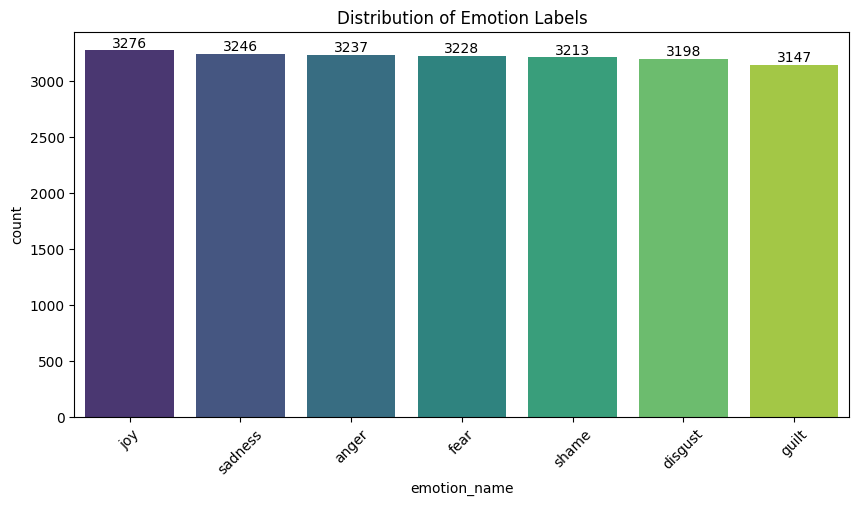

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. LABEL DISTRIBUTION
plt.figure(figsize=(10, 5))
emotion_map = {
    0: 'anger',
    1: 'disgust',
    2: 'sadness',
    3: 'shame',
    4: 'fear',
    5: 'joy',
    6: 'guilt'
}

df['emotion_name'] = df['labels'].map(emotion_map)
ax = sns.countplot(data=df, x='emotion_name', order=df['emotion_name'].value_counts().index, palette='viridis')
plt.title('Distribution of Emotion Labels')
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.show()

/tmp/ipython-input-2708910001.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='labels', y='word_count', ax=ax[1], palette='Set2')


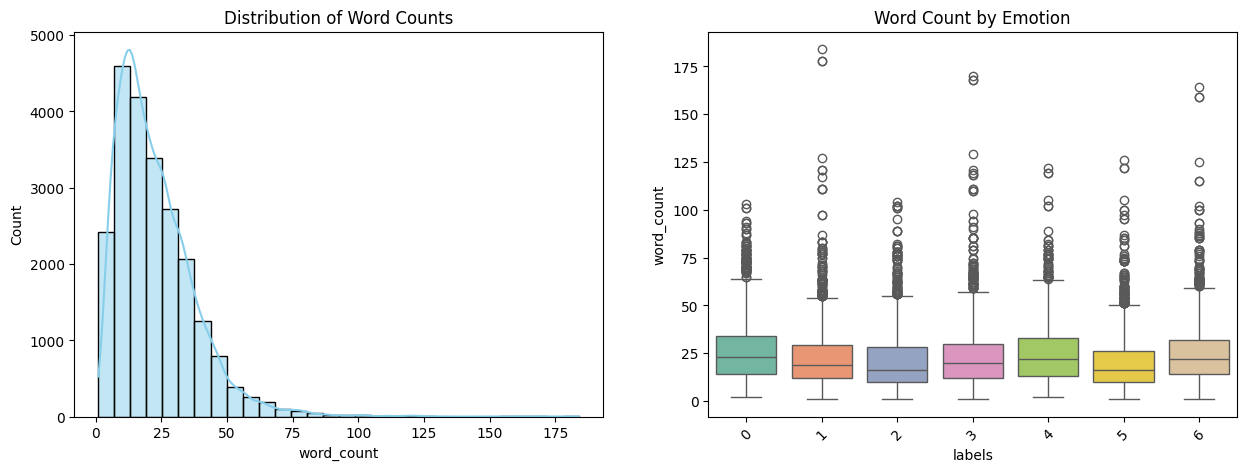

In [ ]:
# 3. TEXT LENGTH ANALYSIS
df['char_count'] = df['content'].astype(str).apply(len)
df['word_count'] = df['content'].astype(str).apply(lambda x: len(x.split()))

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['word_count'], bins=30, kde=True, ax=ax[0], color='skyblue')
ax[0].set_title('Distribution of Word Counts')

sns.boxplot(data=df, x='labels', y='word_count', ax=ax[1], palette='Set2')
ax[1].set_title('Word Count by Emotion')
plt.xticks(rotation=45)
plt.show()

/tmp/ipython-input-4152800886.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=words_df, x='count', y='word', palette='magma')
/tmp/ipython-input-4152800886.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=words_df, x='count', y='word', palette='magma')
/tmp/ipython-input-4152800886.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=words_df, x='count', y='word', palette='magma')


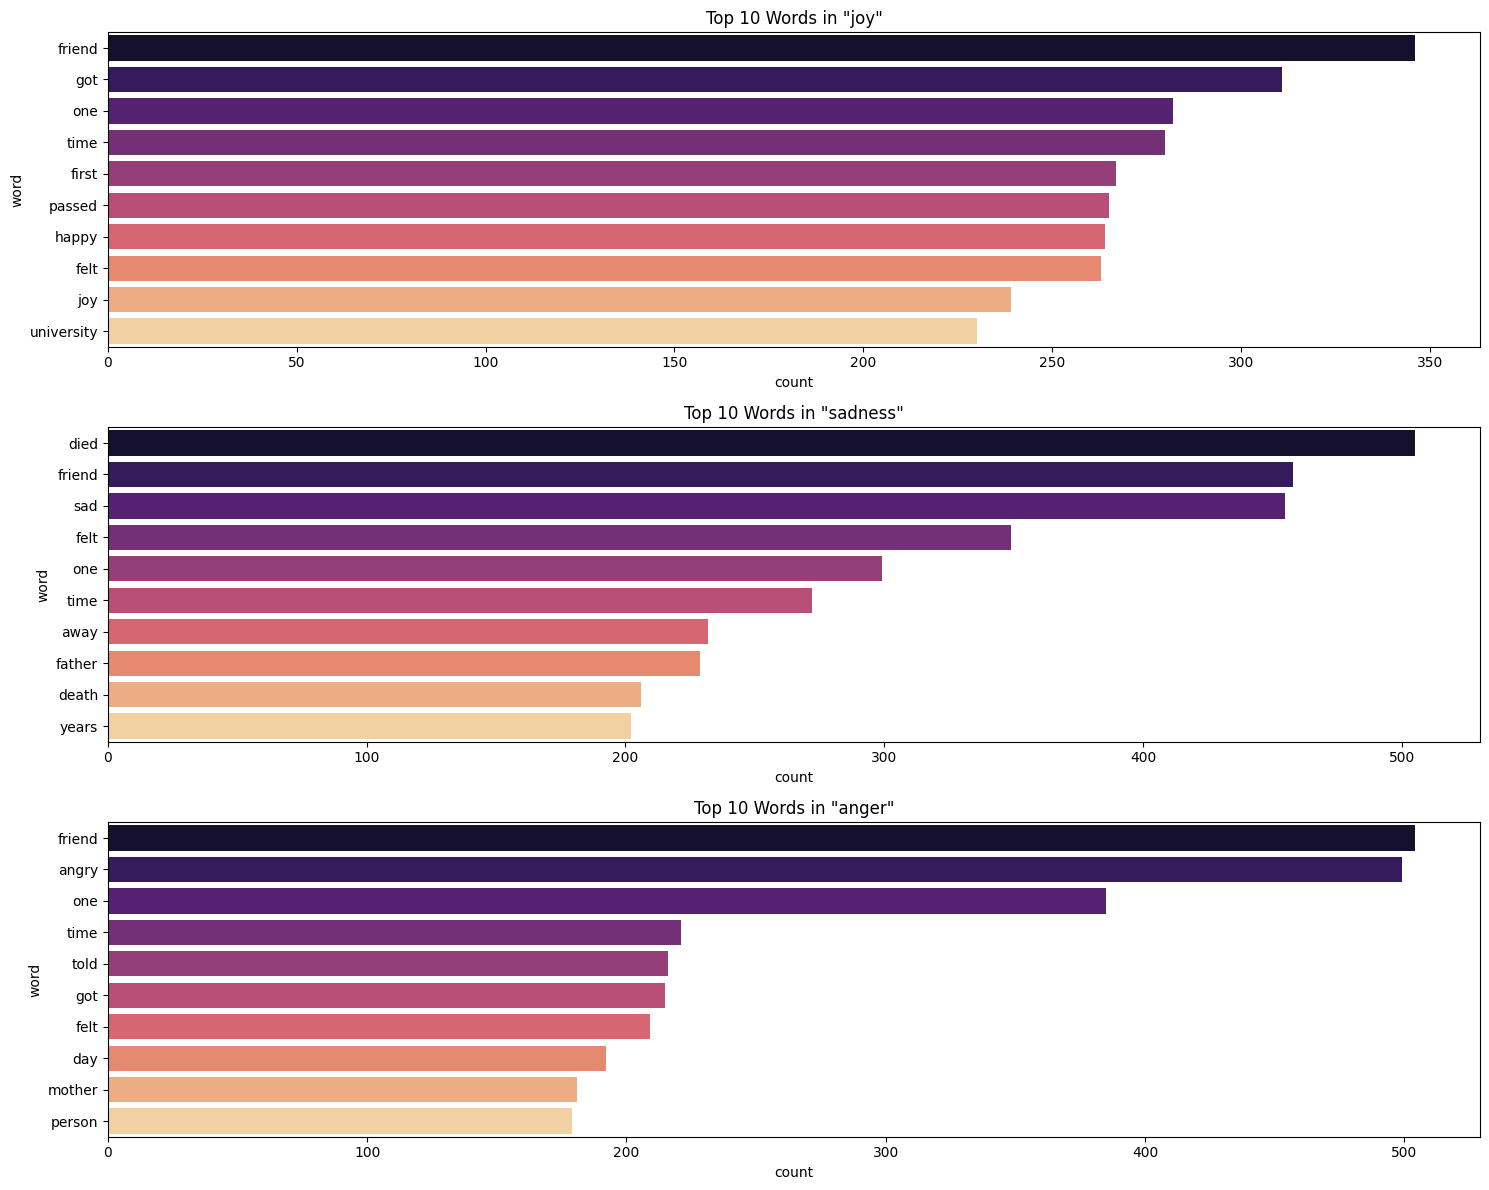

In [ ]:
# 4. TOP WORDS PER EMOTION (N-Gram Analysis)
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text) # Remove punctuation
    words = text.split()
    words = [w for w in words if w not in stop_words] # Remove stopwords
    return words

def plot_top_words(df, label_col, content_col, emotion, n=10):
    subset = df[df[label_col] == emotion][content_col]
    all_words = [word for text in subset for word in clean_text(text)]
    most_common = Counter(all_words).most_common(n)

    words_df = pd.DataFrame(most_common, columns=['word', 'count'])
    sns.barplot(data=words_df, x='count', y='word', palette='magma')
    plt.title(f'Top {n} Words in "{emotion}"')

unique_emotions = df['emotion_name'].value_counts().index[:3]
plt.figure(figsize=(15, 12))
for i, emotion in enumerate(unique_emotions):
    plt.subplot(len(unique_emotions), 1, i+1)
    plot_top_words(df, 'emotion_name', 'content', emotion)
plt.tight_layout()
plt.show()

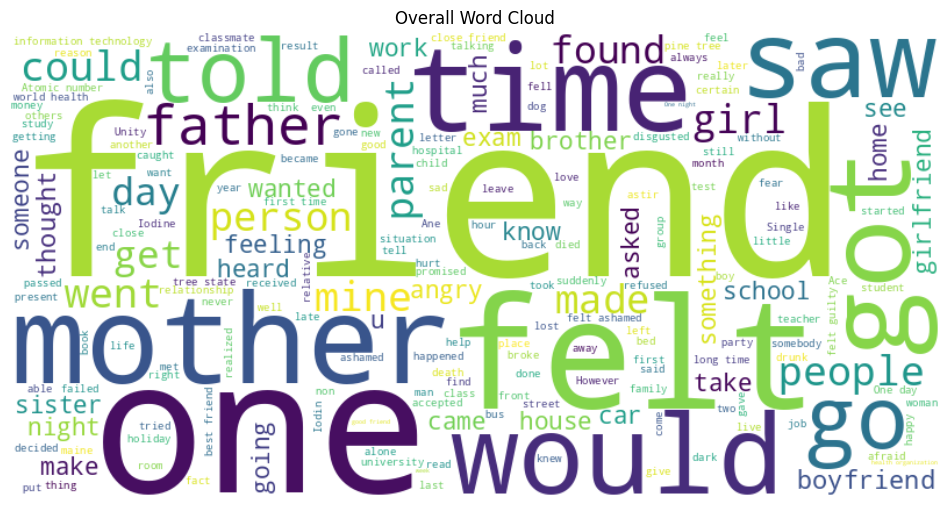

In [ ]:
plt.figure(figsize=(12, 8))
all_text = " ".join(df['content'].astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stop_words).generate(all_text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Overall Word Cloud')
plt.show()

In [ ]:
!pip install spacy textstat
!python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 30.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 73.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Calculating linguistic metrics...


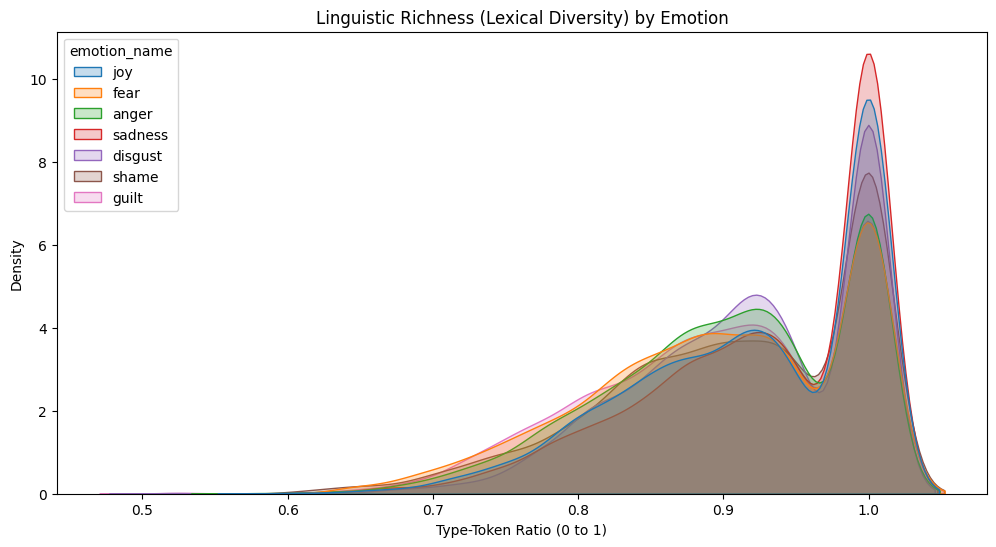

/tmp/ipython-input-2240143056.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='emotion_name', y='readability', palette='coolwarm')


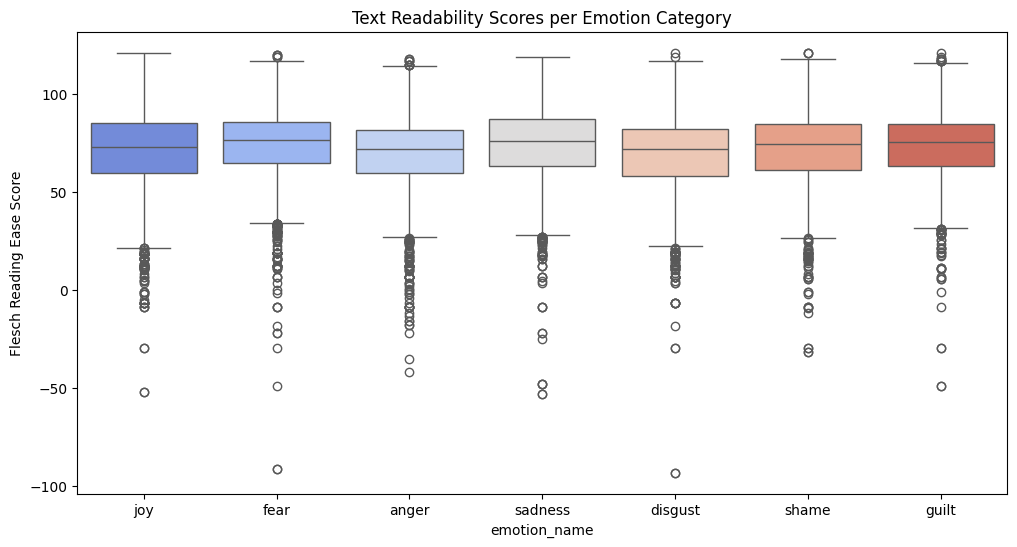


--- Summary Table for Thesis ---
             lexical_diversity readability word_count        
                          mean        mean       mean     std
emotion_name                                                 
anger                    0.904      69.523     25.201  15.477
disgust                  0.919      68.768     21.836  14.783
fear                     0.899      74.225     24.479  15.133
guilt                    0.900      73.274     24.555  15.286
joy                      0.920      71.547     20.118  13.840
sadness                  0.927      74.290     20.327  14.467
shame                    0.909      71.857     22.918  15.342


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import spacy
from textstat import flesch_reading_ease
import numpy as np

nlp = spacy.load("en_core_web_sm")


def get_lexical_diversity(text):
    words = str(text).lower().split()
    if len(words) == 0: return 0
    return len(set(words)) / len(words)

print("Calculating linguistic metrics...")
df['lexical_diversity'] = df['content'].apply(get_lexical_diversity)
df['readability'] = df['content'].apply(lambda x: flesch_reading_ease(str(x)))


plt.figure(figsize=(12, 6))
sns.kdeplot(data=df, x='lexical_diversity', hue='emotion_name', fill=True, common_norm=False)
plt.title('Linguistic Richness (Lexical Diversity) by Emotion')
plt.xlabel('Type-Token Ratio (0 to 1)')
plt.show()


plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='emotion_name', y='readability', palette='coolwarm')
plt.title('Text Readability Scores per Emotion Category')
plt.ylabel('Flesch Reading Ease Score')
plt.show()

thesis_summary = df.groupby('emotion_name').agg({
    'lexical_diversity': 'mean',
    'readability': 'mean',
    'word_count': ['mean', 'std']
}).round(3)

print("\n--- Summary Table for Thesis ---")
print(thesis_summary)

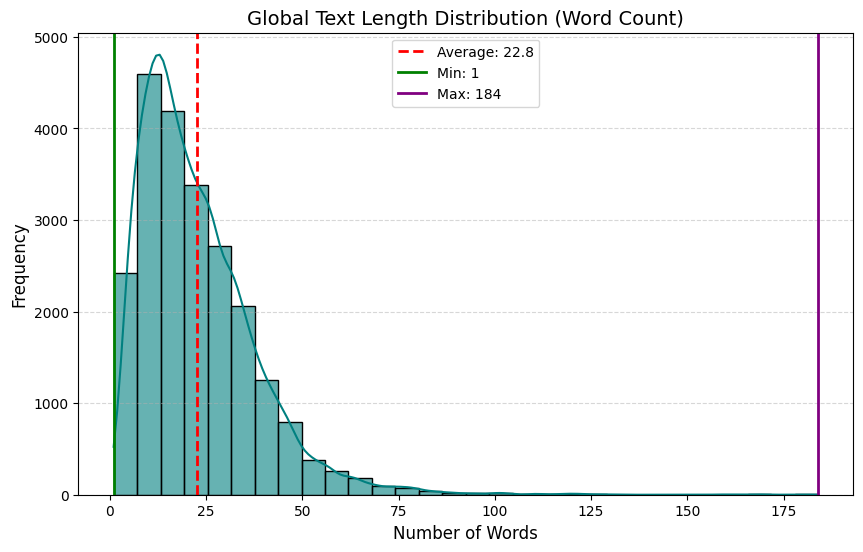

count    22545.000000
mean        22.764338
std         15.032147
min          1.000000
25%         12.000000
50%         20.000000
75%         31.000000
max        184.000000
Name: word_count, dtype: float64


In [ ]:

# 1. Calculate word counts
df['word_count'] = df['content'].astype(str).apply(lambda x: len(x.split()))

# 2. Calculate key metrics
avg_len = df['word_count'].mean()
min_len = df['word_count'].min()
max_len = df['word_count'].max()

# 3. Plot
plt.figure(figsize=(10, 6))
sns.histplot(df['word_count'], bins=30, kde=True, color='teal', alpha=0.6)

# 4. Min, Max, and Average
plt.axvline(avg_len, color='red', linestyle='--', linewidth=2, label=f'Average: {avg_len:.1f}')
plt.axvline(min_len, color='green', linestyle='-', linewidth=2, label=f'Min: {min_len}')
plt.axvline(max_len, color='purple', linestyle='-', linewidth=2, label=f'Max: {max_len}')

plt.title('Global Text Length Distribution (Word Count)', fontsize=14)
plt.xlabel('Number of Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

print(df['word_count'].describe())